## Trabajo Práctico - Estadística Avanzada y Modelos de Regresión
### Análisis de propiedades de Properati
#### Grupo: Aboulafia Gerardo, Barquet Amelie, Lombardo Micaela, Vazquez Agustina
---

In [ ]:
# Imports HOLA jj
#soy agus
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import shapely.wkt
import geopandas as gpd
import geopy.distance
from shapely.geometry import Point, Polygon, MultiPolygon
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, RandomizedSearchCV
from scipy import stats
from shapely.ops import unary_union
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.api as sm

/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/geopandas/_compat.py:111: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


### 1. Estudio de estructura y limpieza preliminar

In [2]:
# Ruta del archivo CSV
file_name_str = "/Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 4/Estadística Avanzada/TP/properaty_dataset_alumnos.csv"

data = pd.read_csv(file_name_str)

# Mostrar información del archivo
print("Data types:"+str(data.dtypes))
print("Data shape:"+str(data.shape))

# Mostrar las primeras filas del archivo
data.head()

Data types:id                           object
start_date                   object
end_date                     object
created_on                   object
latitud                     float64
longitud                    float64
place_l2                     object
place_l3                     object
place_l4                     object
place_l5                     object
place_l6                    float64
operation                    object
property_type                object
property_rooms              float64
property_bedrooms           float64
property_surface_total      float64
property_surface_covered    float64
property_price              float64
property_currency            object
property_title               object
dtype: object
Data shape:(200000, 20)


/var/folders/tl/xv57h3v16hn09tzfc8nklnqw0000gn/T/ipykernel_88481/284029169.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_name_str)


,id,start_date,end_date,created_on,latitud,longitud,place_l2,place_l3,place_l4,place_l5,place_l6,operation,property_type,property_rooms,property_bedrooms,property_surface_total,property_surface_covered,property_price,property_currency,property_title
0,WU6sY9relATTrVzUgo6ijA==,2021-02-22,9999-12-31,2021-02-22,-34.598973,-58.429204,Capital Federal,Villa Crespo,NaN,NaN,NaN,Venta,Departamento,4.0,NaN,107.0,100.0,205000.0,USD,Departamento - Villa Crespo BIEN UBICADO
1,dmEs2Sd/6IjoJNWB0CdbJQ==,2021-12-23,2022-01-27,2021-12-23,-34.583655,-58.501788,Capital Federal,Villa Pueyrredón,NaN,NaN,NaN,Venta,Departamento,2.0,1.0,48.0,45.0,120000.0,USD,"Departamento en venta, Griveo 2746, Villa Puey..."
2,CTFPJk9houRcGjOZcxGvEA==,2021-06-30,9999-12-31,2021-06-30,-34.571827,-58.483719,Capital Federal,Villa Urquiza,NaN,NaN,NaN,Venta,Departamento,1.0,1.0,30.0,27.0,104000.0,USD,HERMOSO DEPARTAMENTO CONTRAFRENTE CON VISTA AB...
3,z6/hBM7rtl3cTg2lsm5ZSQ==,2021-10-16,2021-11-15,2021-10-16,-34.632078,-58.443757,Capital Federal,Parque Chacabuco,NaN,NaN,NaN,Venta,Departamento,3.0,2.0,88.0,84.0,148000.0,USD,DEPARTAMENTO 3 AMB C/ BALCÓN Y DEPENDENCIA · P...
4,icWo1was+O+t6NMP7GzB0Q==,2021-01-16,2021-04-08,2021-01-16,NaN,NaN,Capital Federal,Coghlan,NaN,NaN,NaN,Venta,Departamento,NaN,NaN,NaN,152.0,410404.0,USD,Departamento en Coghlan


In [3]:
# Filtrar el dataset para quedarnos con las propiedades que tienen precio en dolares y están en Capital Federal
data = data[(data['property_currency'] == 'USD') & (data['place_l2'] == 'Capital Federal')]

#filtro de depto, casa, ph
data= data[data['property_type'].isin(['Departamento', 'Casa', 'PH'])]

In [4]:
# Renombrar columnas y sacar el prefijo property
data.columns = data.columns.str.replace('property_', '')

### 2. Data cleaning

#### Estudio de valores nulos

In [5]:
# Eliminamos las columnas place_l5 y place_l6 ya que tienen un 100% de valores nulos. Además eliminamos la columna currency ya que tiene un solo valor, y la columna place_l4 ya que tiene 96% de valores nulos
data  = data.drop(['place_l5', 'place_l6', 'currency', 'place_l4'], axis=1)

#### Imputación de valores para 'rooms'

In [6]:
#data.rename(columns={'title;;;;;': 'title'}, inplace=True)
# Función que utiliza RegEx para encontrar el número de ambientes.
def find_numbers(x_column, x_word):
    """ La función busca en la columna especificada de df la
        palabra deseada y toma el número que la precede. La idea es utilizar
        title|description como columnas y amb|dorm|hab como palabras.
    """
    fix_dict = {
        'un':'1', 'Un':'1', 'UN':'1',
        'mono':'1', 'Mono':'1', 'MONO':'1',
        'dos':'2', 'Dos':'2', 'DOS':'2',
        'tres':'3', 'Tres':'3', 'TRES':'3',
        'cuatro':'4', 'Cuatro':'4', 'CUATRO':'4',
        'cinco':'5', 'Cinco':'5', 'CINCO':'5',
        'seis':'6', 'Seis':'6', 'SEIS':'6',
        'siete':'7', 'Siete':'7', 'SIETE':'7',
        'ocho':'8', 'Ocho':'8', 'OCHO':'8',
        'nueve':'9', 'Nueve':'9', 'NUEVE':'9'
    }

    # Ajustar patrón para que busque también números y el término completo (ej. "3 ambientes")
    pattern = re.compile(r'(?i)(?P<amb>(\w+|\d+))\s*' + x_word)

    re_amb = data[x_column].apply(lambda x: pattern.search(str(x)))
    match_amb = re_amb.apply(lambda x: x.group('amb') if x else None)

    # Reemplazo de palabras por números
    match_amb.replace(fix_dict, inplace=True)
    match_amb.fillna('', inplace=True)
    mask_numeric = match_amb.apply(lambda x: x.isnumeric())
    match_amb[~mask_numeric] = np.nan
    return match_amb

# Función para llenar rooms_total
def fill_rooms_total(x_rooms_total, x_column, x_word):
    """ Llenado del totalizador 'rooms_total' con la combinación correcta de
        title|description como columnas y amb|dorm|hab como palabras.
    """
    rooms_partial = find_numbers(x_column, x_word)

    if x_word == 'ambientes':
        # Convertir directamente a números, reemplazando valores no numéricos con NaN
        rooms_partial = pd.to_numeric(rooms_partial, errors='coerce')
    else:
        # Convertir directamente a números y sumar 1, reemplazando valores no numéricos con NaN
        rooms_partial = pd.to_numeric(rooms_partial, errors='coerce') + 1

    x_rooms_total.fillna(rooms_partial, inplace=True)
    return x_rooms_total

# Inicialización del contador
rooms_total = pd.Series([np.nan for _ in data.rooms])

# Llamados con las diferentes combinaciones con la función mejorada
rooms_total = fill_rooms_total(rooms_total, 'title', 'ambientes')
rooms_total = fill_rooms_total(rooms_total, 'title', 'dorm')
rooms_total = fill_rooms_total(rooms_total, 'title', 'hab')

# Búsqueda de monoambientes
pattern_mono = re.compile('(?i)monoambiente')
re_amb_mono = data['title'].astype(str).apply(lambda x: pattern_mono.search(x))
rooms_partial_mono = re_amb_mono.apply(lambda x: 1 if x is not None else None)
rooms_total.fillna(pd.Series(rooms_partial_mono), inplace=True)

# Guardar el resultado final en el DataFrame
data['rooms_total'] = rooms_total

# Crear una nueva columna 'rooms_final' que sea igual a 'rooms'
data['rooms_final'] = data['rooms']

# Reemplazar los valores nulos en 'rooms_final' con los valores de 'rooms_total'
data['rooms_final'].fillna(data['rooms_total'], inplace=True)

# Comparamos la cantidad de nulos en 'rooms' y 'rooms_final'
print(data['rooms'].isnull().sum())
print(data['rooms_final'].isnull().sum())

1036
803


#### Imputación de valores para 'surface'

In [7]:
# Creamos un patrón para encontrar los metros cuadrados en la columna de descripción.
patron_m2 = r"(\d{2,5})(\s)?(m|mt|mts|metros)(\s)?(2)?"
patron_m2_regex = re.compile(patron_m2, re.IGNORECASE)

# Convertimos la columna 'title' a tipo string si no lo es ya.
title_series = data['title'].astype(str)

# Utilizamos una función lambda para buscar el patrón en cada título.
# Extraemos solo el número (grupo 1)
m2_totales = title_series.apply(lambda x: patron_m2_regex.search(x))

# Extraemos los valores encontrados que no son nulos y aplicamos una función lambda para obtener el número (grupo 1).
m2_totales = m2_totales[m2_totales.notnull()].apply(lambda x: x.group(1))

# Asignamos los valores extraídos a una nueva columna 'm2_descripcion' en el DataFrame, y convertimos a tipo numérico.
data['m2_descripcion'] = m2_totales.astype(float)

# Crear una nueva columna 'm2_final' que sea igual a surface_total
data['m2_final'] = data['surface_total']

# Reemplazar los valores nulos en 'm2_final' con los valores de 'm2_descripcion'
data['m2_final'].fillna(data['m2_descripcion'], inplace=True)

# Comparamos la cantidad de nulos en 'm2_final' con la cantidad de nulos en 'surface_total'
print(f"Nulos en 'surface_total': {data['surface_total'].isnull().sum()}")
print(f"Nulos en 'm2_final': {data['m2_final'].isnull().sum()}")

Nulos en 'surface_total': 4831
Nulos en 'm2_final': 4689


#### Cálculo de features con geolocalización

In [8]:
# Cargar el dataset de barrios de Capital Federal
barrios = gpd.read_file('/Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 4/Estadística Avanzada/TP/barrios.csv')

# Convertir la columna WKT a geometrías
barrios['geometry'] = barrios['WKT'].apply(lambda x: shapely.wkt.loads(x))

# Crear un polígono que combine todos los polígonos de los barrios
combined_polygon = unary_union(barrios['geometry'])

In [9]:
# Verificar si las propiedades están dentro del MultiPolygon
def verificar_propiedades(data, multi_polygon):
    # Separar las filas con y sin valores válidos de latitud y longitud
    data_con_coords = data.dropna(subset=['latitud', 'longitud'])
    data_sin_coords = data[data[['latitud', 'longitud']].isna().any(axis=1)]
    
    # Verificar si los puntos están dentro del MultiPolygon
    puntos = data_con_coords.apply(lambda row: Point(row['longitud'], row['latitud']), axis=1)
    data_con_coords['en_capital'] = puntos.apply(lambda point: multi_polygon.is_valid and multi_polygon.contains(point))
    
    # Unir nuevamente los dataframes
    data_resultante = pd.concat([data_con_coords, data_sin_coords], ignore_index=True)
    return data_resultante

# Aplicar la función al dataframe de propiedades
data = verificar_propiedades(data, combined_polygon)

/var/folders/tl/xv57h3v16hn09tzfc8nklnqw0000gn/T/ipykernel_88481/2651051435.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_con_coords['en_capital'] = puntos.apply(lambda point: multi_polygon.is_valid and multi_polygon.contains(point))


In [10]:
# Creamos un subset con las propiedadedes que tienen ID: [axwZ6U4+1RIdVT+eKpht9w==, XBvKILT8ykNaN5l33IyotQ==, 7B+GKO1ssOYqmCXNvnCNOw==]
subset = data[data['id'].isin(['axwZ6U4+1RIdVT+eKpht9w==', 'XBvKILT8ykNaN5l33IyotQ==', '7B+GKO1ssOYqmCXNvnCNOw=='])]

# Convertimos la columna en_capital a tipo booleano
data['en_capital'] = data['en_capital'].astype(bool)

# Finalmente, removemos las propiedades que no están en Capital Federal
data = data[data['en_capital']]

# Añadimos el subset al dataframe de propiedades que están en Capital Federal
data = pd.concat([data, subset], ignore_index=True)

# Eliminamos las columnas 'en_capital'
data = data.drop(['en_capital'], axis=1)

Queremos comprobar qué variables geográficas influyen en el precio de las propiedades. 

Dado que contamos con la latitud y la longitud de la mayoría de los departamentos, vamos a generar 2 features nuevas para el modelo:
Primero, calcularemos la distancia de la propiedad a la estación de subte más cercana. De esta manera, evaluaremos qué tanto la accesibilidad aumenta el precio del inmueble. Esto lo lograremos con los datos geolocalizados que disponibiliza el Gobierno de la Ciudad de Buenos Aires. 

In [11]:
# Preparamos el DataFrame de las propiedades para el análisis.
geometry = gpd.points_from_xy(data['longitud'], data['latitud'])

# Creamos un GeoDataFrame con las propiedades.
gdf = gpd.GeoDataFrame(data, geometry=geometry)

gdf.loc[:, ['geometry','latitud','longitud']].head()

,geometry,latitud,longitud
0,POINT (-58.42920 -34.59897),-34.598973,-58.429204
1,POINT (-58.50179 -34.58365),-34.583655,-58.501788
2,POINT (-58.48372 -34.57183),-34.571827,-58.483719
3,POINT (-58.44376 -34.63208),-34.632078,-58.443757
4,POINT (-58.49273 -34.57502),-34.575017,-58.492732


In [12]:
# Leemos el archivo de subte.
df_subte = pd.read_csv('/Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 4/Estadística Avanzada/TP/estaciones-de-subte.csv')
df_subte.head()

,long,lat,id,estacion,linea
0,-58.398928,-34.635750,1.0,CASEROS,H
1,-58.400970,-34.629376,2.0,INCLAN - MEZQUITA AL AHMAD,H
2,-58.402323,-34.623092,3.0,HUMBERTO 1°,H
3,-58.404732,-34.615242,4.0,VENEZUELA,H
4,-58.406036,-34.608935,5.0,ONCE - 30 DE DICIEMBRE,H


In [13]:
# Transformamos el dataframe en un GeoDataFrame.
geometry_subte = gpd.points_from_xy(df_subte['long'], df_subte['lat'])

geo_subte = gpd.GeoDataFrame(df_subte, geometry=geometry_subte)

# Eliminamos las propiedades que no tienen coordenadas para poder hacer el análisis. Posteriormente se combinarán con las propiedades que no tienen coordenadas.
gdf_clean = gdf.dropna(subset=['latitud', 'longitud'])

In [14]:
# Creamos una función que nos permita encontrar la distancia de cada propiedad al subte más cercano.
def distancia_a_subte_cercano(x):
    # Coordenadas de la propiedad.
    prop = Point(x['longitud'], x['latitud'])
    # Calculamos la distancia entre la propiedad y todas las estaciones de subte.
    distancias = geo_subte['geometry'].apply(lambda y: geopy.distance.geodesic((prop.y, prop.x), (y.y, y.x)).km)
    # Devolvemos la distancia a la estación de subte más cercana.
    return distancias.min()

# Aplicamos la función a cada propiedad y guardamos los resultados en una nueva columna 'distancia_subte_caseros'.
gdf_clean['distancia_subte_cercano'] = gdf_clean.apply(distancia_a_subte_cercano, axis=1)

# Volvemos a unir el GeoDataFrame con las propiedades que no tienen coordenadas.
data = gdf.merge(gdf_clean[['distancia_subte_cercano']], left_index=True, right_index=True, how='left')

/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/geopandas/geodataframe.py:1351: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [15]:
# Eliminar datos erróneos, como precios, superficies o ambientes negativos
data = data[(data['price'] > 0) & (data['m2_final'] > 0) & (data['rooms_final'] > 0)]

In [16]:
# Dividimos el dataset en 80% entrenamiento y 20% prueba
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

# Imprimimos el tamaño de cada conjunto
print(f'Tamaño del conjunto de entrenamiento: {train_df.shape[0]}')
print(f'Tamaño del conjunto de prueba: {test_df.shape[0]}')

Tamaño del conjunto de entrenamiento: 69736
Tamaño del conjunto de prueba: 17434


#### 3.1 Análisis del dataset train_df

Cantidad de outliers en Casas: 187
Cantidad de outliers en Departamentos: 5391
Cantidad de outliers en PH: 209


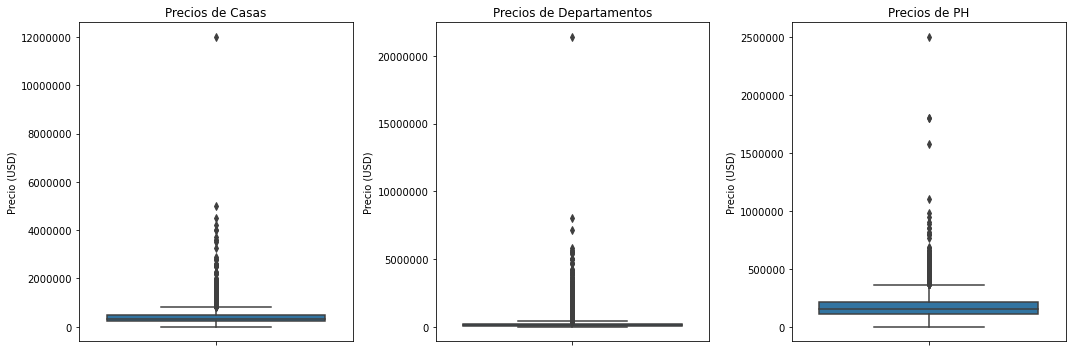

In [17]:
# Filtrar por tipo de propiedad: Casa, Departamento, PH
casas = train_df[train_df['type'] == 'Casa']
departamentos = train_df[train_df['type'] == 'Departamento']
ph = train_df[train_df['type'] == 'PH']

# Función para contar outliers usando el método IQR
def contar_outliers(df, columna):
    # Calcular cuartiles y rango intercuartílico
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites para identificar outliers
    rango_inferior = Q1 - 1.5 * IQR
    rango_superior = Q3 + 1.5 * IQR * 1.1

    # Contar outliers
    outliers = df[(df[columna] < rango_inferior) | (df[columna] > rango_superior)]
    return outliers.shape[0]

# Contar outliers en cada tipo de propiedad
cantidad_outliers_casas = contar_outliers(casas, 'price')
cantidad_outliers_departamentos = contar_outliers(departamentos, 'price')
cantidad_outliers_ph = contar_outliers(ph, 'price')

# Imprimir la cantidad de outliers para cada tipo de propiedad
print(f'Cantidad de outliers en Casas: {cantidad_outliers_casas}')
print(f'Cantidad de outliers en Departamentos: {cantidad_outliers_departamentos}')
print(f'Cantidad de outliers en PH: {cantidad_outliers_ph}')

# Crear una figura con 3 subgráficos (boxplots) para cada tipo de propiedad
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot para las Casas
sns.boxplot(data=casas, y='price', ax=axs[0])
axs[0].set_title('Precios de Casas')
axs[0].set_ylabel('Precio (USD)')
axs[0].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Boxplot para los Departamentos
sns.boxplot(data=departamentos, y='price', ax=axs[1])
axs[1].set_title('Precios de Departamentos')
axs[1].set_ylabel('Precio (USD)')
axs[1].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Boxplot para los PH
sns.boxplot(data=ph, y='price', ax=axs[2])
axs[2].set_title('Precios de PH')
axs[2].set_ylabel('Precio (USD)')
axs[2].ticklabel_format(style='plain', axis='y')  # Desactivar notación científica

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

En estos 3 boxplots vemos cómo encontramos valores extremos para casas y departamentos en mayor medida. Sin embargo, eliminaremos los outliers para contar con datos de mejor calidad

In [18]:
# Definir la función para eliminar outliers
def eliminar_outliers(df, columna):
    # Calcular cuartiles y rango intercuartílico
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Rango ajustado (ampliar el rango superior en un 10%)
    rango_inferior = Q1 - 1.5 * IQR
    rango_superior = Q3 + 1.5 * IQR * 1.1

    # Filtrar valores dentro del rango
    df_filtrado = df[(df[columna] >= rango_inferior) & (df[columna] <= rango_superior)]
    
    return df_filtrado

# Aplicar la función para eliminar outliers
casas_limpio = eliminar_outliers(casas, 'price')
departamentos_limpio = eliminar_outliers(departamentos, 'price')
ph_limpio = eliminar_outliers(ph, 'price')

# Unir todos los DataFrames limpios
clean_train_df = pd.concat([casas_limpio, departamentos_limpio, ph_limpio], ignore_index=True)

# Validar la eliminación de outliers
def validar_remocion_outliers(df_original, df_limpio, cantidad_outliers):
    # Calcular la diferencia en la cantidad de filas
    filas_originales = df_original.shape[0]
    filas_limpias = df_limpio.shape[0]
    filas_eliminadas = filas_originales - filas_limpias

    # Verificar si la cantidad de filas eliminadas coincide con los outliers identificados
    if filas_eliminadas == cantidad_outliers:
        print("Validación exitosa: Se eliminaron correctamente los", cantidad_outliers, "outliers.")
    else:
        print(f"Advertencia: La cantidad de outliers eliminados ({filas_eliminadas}) no coincide con la cantidad identificada ({cantidad_outliers}).")

# Validar para cada tipo de propiedad
validar_remocion_outliers(casas, casas_limpio, cantidad_outliers_casas)
validar_remocion_outliers(departamentos, departamentos_limpio, cantidad_outliers_departamentos)
validar_remocion_outliers(ph, ph_limpio, cantidad_outliers_ph)
train_df = clean_train_df

Validación exitosa: Se eliminaron correctamente los 187 outliers.
Validación exitosa: Se eliminaron correctamente los 5391 outliers.
Validación exitosa: Se eliminaron correctamente los 209 outliers.


In [19]:
# Contar la cantidad de propiedades con precios menores a 10000 USD
print(train_df[train_df['price'] < 10000].shape[0])

# Eliminar las propiedades con precios menores a 10000 USD
train_df = train_df[train_df['price'] >= 10000]

1261


In [20]:
train_df[(train_df['m2_final'] > 700) & (train_df['type'] == 'Departamento')].shape[0]

52

In [21]:
# Filtrar los registros que son de tipo "Departamento"
dept_mask_train = (train_df['type'] == 'Departamento')

# Reemplazar surface_total por surface_covered cuando surface_total es más del doble que surface_covered
train_df.loc[dept_mask_train & (train_df['surface_total'] > 2 * train_df['surface_covered']), 'surface_total'] = train_df['surface_covered']

# Reemplazar m2_final por surface_covered cuando m2_final es más del doble que surface_covered
train_df.loc[dept_mask_train & (train_df['m2_final'] > 2 * train_df['surface_covered']), 'm2_final'] = train_df['surface_covered']

train_df = train_df[~(dept_mask_train & (train_df['surface_total'] > 800))]

In [22]:
filtered_df_train = train_df[(train_df['type'].isin(['Departamento', 'PH'])) & (train_df['bedrooms'] > 15)]

Los inmuebles que tengan más de 15 habitaciones y estén clasificados como departamentos o PHs, pero cuya descripción contenga la palabra "hotel", serán eliminados. 

In [23]:
train_df = train_df[~((train_df['bedrooms'] > 15) & (train_df['title'].str.contains('hotel', case=False)))]
train_df[(train_df['type'].isin(['Departamento', 'PH'])) & (train_df['bedrooms'] > 15)]

,id,start_date,end_date,created_on,latitud,longitud,place_l2,place_l3,operation,type,...,surface_total,surface_covered,price,title,rooms_total,rooms_final,m2_descripcion,m2_final,geometry,distancia_subte_cercano
10759,r3sXlEIiCgBG5TtUkN93mw==,2021-03-14,2021-06-05,2021-03-14,-34.608645,-58.485619,Capital Federal,Villa del Parque,Venta,Departamento,...,83.0,75.0,189000.0,Departamento 4 ambientes a estrenar en duplex ...,4.0,4.0,NaN,83.0,POINT (-58.48562 -34.60864),2.852656
27455,cMA0xBBQnANFa/wNTQtZcw==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Almagro,Venta,Departamento,...,111.0,76.0,270000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT EMPTY,NaN
30493,yzI9zylc11wllHX16av6jA==,2021-09-30,2021-11-02,2021-09-30,-34.632537,-58.360577,Capital Federal,Boca,Venta,Departamento,...,372.0,318.0,139000.0,DEPARTAMENTO PH 19 AMBIENTES AV ALMTE BROWN BOCA,19.0,19.0,NaN,372.0,POINT (-58.36058 -34.63254),1.988877
36677,f48xnLslZAFNd6aFyB7MZA==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Caballito,Venta,Departamento,...,111.0,76.0,245000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT EMPTY,NaN
40160,pVG9sES9De/1eQ+tB90NjQ==,2021-03-26,2021-06-05,2021-03-26,-34.591110,-58.400685,Capital Federal,Recoleta,Venta,Departamento,...,148.0,138.0,380000.0,Departamento. Recoleta. Balcón terraza. Silenc...,NaN,4.0,NaN,148.0,POINT (-58.40068 -34.59111),0.399894
43030,UVuiurLBb+DzTf73JSOI4g==,2021-04-13,2021-06-05,2021-04-13,NaN,NaN,Capital Federal,Almagro,Venta,Departamento,...,111.0,76.0,245000.0,Excelente y único Departamento en duplex a nue...,NaN,3.0,NaN,111.0,POINT EMPTY,NaN
57877,uqM9/WXFJkEJnXEQefcpRQ==,2021-09-19,2021-09-19,2021-09-19,-34.611905,-58.382384,Capital Federal,Monserrat,Venta,PH,...,587.0,276.0,299900.0,PH DE16 HABITACIONES IDEAL PARA HOSTEL A RECI...,NaN,15.0,NaN,587.0,POINT (-58.38238 -34.61191),0.194591
58634,+SPkA/Y4DHEHf+HIppYFKg==,2021-03-31,2021-04-16,2021-03-31,-34.611905,-58.382384,Capital Federal,Monserrat,Venta,PH,...,587.0,276.0,349000.0,PH DE16 HABITACIONES IDEAL PARA HOSTEL A RECI...,NaN,15.0,NaN,587.0,POINT (-58.38238 -34.61191),0.194591
59273,KA441xdi8PtuWBvjcAbGOQ==,2021-02-08,2021-03-01,2021-02-08,-34.632698,-58.360514,Capital Federal,Boca,Venta,PH,...,372.0,318.0,159000.0,PH 18 HABITACIONES AV ALMTE BROWN LA BOCA,19.0,19.0,NaN,372.0,POINT (-58.36051 -34.63270),1.999377


In [24]:
# Aplicar la función para eliminar outliers
casas_limpio = eliminar_outliers(casas, 'price')
departamentos_limpio = eliminar_outliers(departamentos, 'price')
ph_limpio = eliminar_outliers(ph, 'price')

# Unir todos los DataFrames limpios
clean_test_df = pd.concat([casas_limpio, departamentos_limpio, ph_limpio], ignore_index=True)

# Validar para cada tipo de propiedad
validar_remocion_outliers(casas, casas_limpio, cantidad_outliers_casas)
validar_remocion_outliers(departamentos, departamentos_limpio, cantidad_outliers_departamentos)
validar_remocion_outliers(ph, ph_limpio, cantidad_outliers_ph)
test_df = clean_test_df

Validación exitosa: Se eliminaron correctamente los 187 outliers.
Validación exitosa: Se eliminaron correctamente los 5391 outliers.
Validación exitosa: Se eliminaron correctamente los 209 outliers.


In [25]:
# Contar la cantidad de propiedades con precios menores a 10000 USD
print(test_df[test_df['price'] < 10000].shape[0])

# Eliminar las propiedades con precios menores a 10000 USD
test_df = test_df[test_df['price'] >= 10000]

1261


In [26]:
test_df[(test_df['m2_final'] > 700) & (test_df['type'] == 'Departamento')].shape[0]

52

In [27]:
# Filtrar los registros que son de tipo "Departamento"
dept_mask_test = (test_df['type'] == 'Departamento')

# Reemplazar surface_total por surface_covered cuando surface_total es más del doble que surface_covered
test_df.loc[dept_mask_test & (test_df['surface_total'] > 2 * test_df['surface_covered']), 'surface_total'] = test_df['surface_covered']

# Reemplazar m2_final por surface_covered cuando m2_final es más del doble que surface_covered
test_df.loc[dept_mask_test & (test_df['m2_final'] > 2 * test_df['surface_covered']), 'm2_final'] = test_df['surface_covered']

test_df = test_df[~(dept_mask_test & (test_df['surface_total'] > 700))]

Lo mismo se hace con la cantidad de habitaciones, si existen datos que tengan más habitaciones que ambientes

In [28]:
test_df = test_df[~(test_df['bedrooms'] > test_df['rooms_final'])]

In [30]:
import pandas as pd
from scipy import stats

# Hacer una copia de los dataframes originales
train_df_copy = train_df.copy()
test_df_copy = test_df.copy()

# 1. Comparar 'train_df' antes y después de la imputación
# Test de Kolmogorov-Smirnov en los datos originales de train (antes de la imputación)
ks_stat_train_before, p_value_train_before = stats.ks_2samp(train_df['distancia_subte_cercano'].dropna(), train_df_copy['distancia_subte_cercano'].dropna())
print(f"Train - Antes de la imputación:")
print(f'Estadístico K-S: {ks_stat_train_before}')
print(f'Valor p: {p_value_train_before}')
if p_value_train_before < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.\n')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.\n')

# Imputar los valores nulos en el DataFrame 'train_df' con la media por 'place_l3'
train_df_copy['distancia_subte_cercano'] = train_df_copy.groupby('place_l3')['distancia_subte_cercano'].transform(lambda x: x.fillna(x.mean()))

# Test de Kolmogorov-Smirnov en los datos de train (después de la imputación)
ks_stat_train_after, p_value_train_after = stats.ks_2samp(train_df['distancia_subte_cercano'].dropna(), train_df_copy['distancia_subte_cercano'].dropna())
print(f"Train - Después de la imputación:")
print(f'Estadístico K-S: {ks_stat_train_after}')
print(f'Valor p: {p_value_train_after}')
if p_value_train_after < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.\n')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.\n')


# 2. Comparar 'test_df' antes y después de la imputación
# Test de Kolmogorov-Smirnov en los datos originales de test (antes de la imputación)
ks_stat_test_before, p_value_test_before = stats.ks_2samp(test_df['distancia_subte_cercano'].dropna(), test_df_copy['distancia_subte_cercano'].dropna())
print(f"Test - Antes de la imputación:")
print(f'Estadístico K-S: {ks_stat_test_before}')
print(f'Valor p: {p_value_test_before}')
if p_value_test_before < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.\n')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.\n')

# Imputar los valores nulos en el DataFrame 'test_df' con la media por 'place_l3'
test_df_copy['distancia_subte_cercano'] = test_df_copy.groupby('place_l3')['distancia_subte_cercano'].transform(lambda x: x.fillna(x.mean()))

# Test de Kolmogorov-Smirnov en los datos de test (después de la imputación)
ks_stat_test_after, p_value_test_after = stats.ks_2samp(test_df['distancia_subte_cercano'].dropna(), test_df_copy['distancia_subte_cercano'].dropna())
print(f"Test - Después de la imputación:")
print(f'Estadístico K-S: {ks_stat_test_after}')
print(f'Valor p: {p_value_test_after}')
if p_value_test_after < 0.05:
    print('Se rechaza la hipótesis nula: Las distribuciones son diferentes.\n')
else:
    print('No se rechaza la hipótesis nula: Las distribuciones son iguales.\n')

Train - Antes de la imputación:
Estadístico K-S: 0.0
Valor p: 1.0
No se rechaza la hipótesis nula: Las distribuciones son iguales.

Train - Después de la imputación:
Estadístico K-S: 0.010205463834251582
Valor p: 0.0032847968598556606
Se rechaza la hipótesis nula: Las distribuciones son diferentes.

Test - Antes de la imputación:
Estadístico K-S: 0.0
Valor p: 1.0
No se rechaza la hipótesis nula: Las distribuciones son iguales.

Test - Después de la imputación:
Estadístico K-S: 0.01018341553325719
Valor p: 0.00340364236054391
Se rechaza la hipótesis nula: Las distribuciones son diferentes.



Vemos que las distribuciones son iguales. Por lo que tomamos como válida la imputación y reemplazamos el dataset creado por el 

In [31]:
# Reemplazar los datasets originales con los datasets imputados
train_df = train_df_copy
test_df = test_df_copy

Tenemos muy pocos datos con place_l3 con nulos. Estos datos complican la imputación de valores, y serán problemáticos más adelante.

In [32]:
# Remover las filas con valores nulos en 'place_l3'
train_df = train_df.dropna(subset=['place_l3'])

test_df = test_df.dropna(subset=['place_l3'])

# A partir de aquí, tenemos que entrenar el XGBoost y guardar el modelo

In [33]:
# Eliminar id, start_date, end_date, created_on, latitud, longitud, place_l2, operation, type, rooms, bedrooms, surface_total, surface_covered, title, geometry, m2_descripcion]
train_df = train_df.drop(['id', 'start_date', 'end_date', 'created_on', 'latitud', 'longitud', 'place_l2', 'operation',  'rooms', 'bedrooms', 'surface_total', 'surface_covered', 'title', 'geometry', 'm2_descripcion'], axis=1)

In [34]:
# Eliminar id, start_date, end_date, created_on, latitud, longitud, place_l2, operation, type, rooms, bedrooms, surface_total, surface_covered, title, geometry, m2_descripcion]
test_df = test_df.drop(['id', 'start_date', 'end_date', 'created_on', 'latitud', 'longitud', 'place_l2', 'operation', 'rooms', 'bedrooms', 'surface_total', 'surface_covered', 'title', 'geometry', 'm2_descripcion'], axis=1)

In [35]:
# Eliminar rooms_total
train_df = train_df.drop(['rooms_total'], axis=1)
test_df = test_df.drop(['rooms_total'], axis=1)

In [36]:
# Normalizar las variables numéricas

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar el escalador con el conjunto de entrenamiento
scaler.fit(train_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']])

StandardScaler()

In [37]:
# # Escalar las variables numéricas
# train_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']] = scaler.transform(train_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']])

# # Ajustar el escalador con el conjunto de prueba
# scaler.fit(test_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']])

# # Escalar las variables numéricas
# test_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']] = scaler.transform(test_df[['rooms_final', 'm2_final', 'distancia_subte_cercano']])

# Separar las variables independientes y la variable objetivo
X_train = train_df.drop('price', axis=1)
y_train = train_df['price']

# Separar las variables independientes y la variable objetivo
X_test = test_df.drop('price', axis=1)
y_test = test_df['price']

In [38]:
X_train

,place_l3,type,rooms_final,m2_final,distancia_subte_cercano
0,Villa Urquiza,Casa,5.0,291.0,1.505223
1,Caballito,Casa,4.0,322.0,1.029724
2,Saavedra,Casa,4.0,220.0,1.259561
3,Villa Devoto,Casa,5.0,165.0,3.969751
4,Villa del Parque,Casa,5.0,350.0,4.122666
...,...,...,...,...,...
63944,San Cristobal,PH,3.0,91.0,0.320239
63945,Belgrano,PH,3.0,85.0,1.069266
63946,Parque Chacabuco,PH,2.0,70.0,0.709141
63947,Parque Chas,PH,2.0,46.0,1.095106


In [39]:
X_train.columns

Index(['place_l3', 'type', 'rooms_final', 'm2_final',
       'distancia_subte_cercano'],
      dtype='object')

In [54]:
import pandas as pd

# 1) Detectar columnas object
obj_cols = X_train.select_dtypes(include='object').columns

# 2) Convertir a category en X_train
for c in obj_cols:
    X_train[c] = X_train[c].astype('category')

# 3) (Opcional) si ya existe X_test, alinear categorías con las de X_train
if 'X_test' in globals():
    for c in obj_cols:
        X_test[c] = pd.Categorical(X_test[c], categories=X_train[c].cat.categories)

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, GridSearchCV

model_xg = XGBRegressor(
    n_jobs=1,                # evita sobre-suscripción con joblib
    random_state=5,
    enable_categorical=True,
    tree_method='hist',      # NECESARIO para categóricas nativas
    eval_metric='rmse'
)

params_xgb = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 3]
}

cv = KFold(n_splits=5, random_state=41, shuffle=True)

grid_search = GridSearchCV(
    model_xg,
    param_grid=params_xgb,
    cv=cv,
    verbose=1,
    n_jobs=2,
    error_score='raise',
    scoring='neg_root_mean_squared_error'

)

grid_search.fit(X_train, y_train)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/geopandas/_compat.py:111: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/geopandas/_compat.py:111: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1500, n_jobs=1,
             num_parallel_tree=None, random_state=5, ...)


In [55]:
print("Mejor score de CV:", grid_search.best_score_)
print("Mejores parámetros:", grid_search.best_params_)

Mejor score de CV: -42157.097962480795
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 1500}


In [56]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Make predictions using the best model
y_train_pred = grid_search.best_estimator_.predict(X_train)
y_test_pred = grid_search.best_estimator_.predict(X_test)

# Calculate RMSE for training and test sets
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"RMSE Difference: ${abs(test_rmse - train_rmse):,.2f}")

Training RMSE: $37,825.91
Test RMSE: $37,815.90
RMSE Difference: $10.00


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 26152.76549531763
RMSE: 37815.90337716991
R²  : 0.8403468200685345


In [58]:
# MAPE: porcentaje medio de error absoluto
mape = (abs(y_test - y_pred) / y_test).mean() * 100
print(f"MAPE: {mape:.2f}%")

# Desviación estándar del target (para dimensionar RMSE)
print(f"Std. precio real: {y_test.std():,.0f} USD")
print(f"RMSE / std: {train_rmse / y_test.std():.2f}")

MAPE: 18.23%
Std. precio real: 94,643 USD
RMSE / std: 0.40


In [59]:
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values("mean_test_score", ascending=False)

# Mostrar top 5 combinaciones
print(cv_results[[
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head())

   param_n_estimators param_learning_rate param_max_depth  mean_test_score  \
11               1500                 0.1               3    -42157.097962   
10               1000                 0.1               3    -42274.382497   
9                 500                 0.1               3    -42575.203140   
8                1500                 0.1               2    -43246.661868   
7                1000                 0.1               2    -43323.969546   

    std_test_score  rank_test_score  
11      449.842226                1  
10      431.686248                2  
9       468.541834                3  
8       406.444436                4  
7       439.228110                5  


In [60]:
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
11,1.554858,0.019462,0.245659,0.002242,0.1,3,1500,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",-42979.219752,-42180.462114,-41719.701616,-42127.374563,-41778.731767,-42157.097962,449.842226,1
10,1.046559,0.011188,0.168990,0.002866,0.1,3,1000,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",-43049.236300,-42257.011686,-41852.083732,-42326.511162,-41887.069603,-42274.382497,431.686248,2
9,0.554650,0.008991,0.089013,0.001653,0.1,3,500,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",-43411.357115,-42624.755451,-42125.782999,-42579.430350,-42134.689784,-42575.203140,468.541834,3
8,1.171096,0.014743,0.136736,0.002724,0.1,2,1500,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",-43952.307212,-43095.043008,-42806.174680,-43418.570179,-42961.214261,-43246.661868,406.444436,4
7,0.815480,0.012762,0.095727,0.001997,0.1,2,1000,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",-44099.626823,-43158.566985,-42856.516006,-43483.756703,-43021.381214,-43323.969546,439.228110,5
5,1.771264,0.025191,0.272732,0.002959,0.01,3,1500,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",-44347.102234,-43249.587714,-43124.393180,-43570.271599,-42952.258569,-43448.722659,492.581148,6
6,0.423772,0.004480,0.050667,0.000548,0.1,2,500,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",-44451.799610,-43563.466409,-43136.551482,-43830.406503,-43329.852707,-43662.415342,457.879929,7
4,1.257237,0.011401,0.194474,0.002588,0.01,3,1000,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",-44657.436006,-43560.785400,-43461.466798,-43853.625066,-43197.332725,-43746.129199,501.716660,8
2,1.343123,0.016151,0.154888,0.000807,0.01,2,1500,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est...",-45616.342680,-44407.765761,-44221.014931,-44835.192714,-44081.848373,-44632.432892,553.547358,9
3,0.682783,0.006426,0.103242,0.002374,0.01,3,500,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",-45692.657166,-44585.074098,-44535.630951,-44739.459697,-44064.638189,-44723.492020,534.429737,10


In [43]:
import joblib

# Save the best model from GridSearchCV
joblib.dump(grid_search.best_estimator_, 'Pipeline/models/xgboost_property_model2.pkl')

['Pipeline/models/xgboost_property_model2.pkl']

In [44]:
X_train.columns

Index(['place_l3', 'type', 'rooms_final', 'm2_final',
       'distancia_subte_cercano'],
      dtype='object')

In [61]:
import json, joblib
import pandas as pd

FEATURES = ['place_l3', 'type', 'rooms_final', 'm2_final', 'distancia_subte_cercano']
CATEGORICALS = ['place_l3', 'type']
NUMERICS = ['rooms_final', 'm2_final', 'distancia_subte_cercano']

# Asegurar dtypes
for c in CATEGORICALS:
    X_train[c] = X_train[c].astype('category')

# (tu GridSearch como ya lo tenés) -> grid_search.best_estimator_
best_model = grid_search.best_estimator_

# Guardar modelo
joblib.dump(best_model, 'Pipeline/models/xgboost_property_model3.pkl')

# Guardar metadatos de categorías y features
cat_map = {c: X_train[c].cat.categories.tolist() for c in CATEGORICALS}
meta = {
    "features": FEATURES,
    "categoricals": CATEGORICALS,
    "numerics": NUMERICS,
    "categories": cat_map
}
with open('Pipeline/models/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

In [64]:
import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

# Define columnas del modelo (las que querés usar)
FEATURES = ['place_l3', 'type', 'rooms_final', 'm2_final', 'distancia_subte_cercano']
CAT_COLS = ['place_l3', 'type']
NUM_COLS = ['rooms_final', 'm2_final', 'distancia_subte_cercano']

# Preprocesamiento
cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse=True))  # sin metadata y tolera categorías nuevas
])

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

pre = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, CAT_COLS),
        ('num', num_pipe, NUM_COLS),
    ],
    remainder='drop'  # ignora cualquier columna extra (p.ej., 'flag')
)

# Modelo
xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.1,
    max_depth=3,
    random_state=5,
    n_jobs=1,
    tree_method='hist',
    eval_metric='rmse'
)

# Pipeline final
pipe = Pipeline(steps=[
    ('pre', pre),
    ('model', xgb)
])

# Entrenar
pipe.fit(X_train[FEATURES], y_train)

# Guardar TODO en un solo .pkl
joblib.dump(pipe, 'Pipeline/models/xgb_pipeline2.pkl')

/Users/gerardoaboulafia/opt/anaconda3/envs/dhdsblend2021/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


['Pipeline/models/xgb_pipeline2.pkl']

In [65]:
# Calculate metrics on training and test sets
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features used in the model
FEATURES = ['place_l3', 'type', 'rooms_final', 'm2_final', 'distancia_subte_cercano']

# Make predictions on training set
y_train_pred = pipe.predict(X_train[FEATURES])

# Make predictions on test set  
y_test_pred = pipe.predict(X_test[FEATURES])

# Calculate metrics for training set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Calculate metrics for test set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# Display results
print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"{'Metric':<15} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*50)
print(f"{'MAE':<15} ${train_mae:,.2f}{'':<7} ${test_mae:,.2f}{'':<7} ${abs(test_mae - train_mae):,.2f}")
print(f"{'RMSE':<15} ${train_rmse:,.2f}{'':<7} ${test_rmse:,.2f}{'':<7} ${abs(test_rmse - train_rmse):,.2f}")
print(f"{'R²':<15} {train_r2:.4f}{'':<10} {test_r2:.4f}{'':<10} {abs(test_r2 - train_r2):.4f}")
print("="*50)

# Calculate percentage differences
mae_diff_pct = ((test_mae - train_mae) / train_mae) * 100
rmse_diff_pct = ((test_rmse - train_rmse) / train_rmse) * 100

print(f"MAE difference: {mae_diff_pct:+.2f}%")
print(f"RMSE difference: {rmse_diff_pct:+.2f}%")

# Overfitting/Underfitting analysis
if abs(test_r2 - train_r2) < 0.05:
    print("✓ Model appears well-balanced (minimal overfitting)")
elif test_r2 < train_r2 - 0.05:
    print("⚠ Potential overfitting detected")
else:
    print("⚠ Potential underfitting detected")

MODEL PERFORMANCE METRICS
Metric          Training        Test            Difference     
--------------------------------------------------
MAE             $27,206.90        $27,193.72        $13.17
RMSE            $39,273.48        $39,253.70        $19.79
R²              0.8280           0.8280           0.0001
MAE difference: -0.05%
RMSE difference: -0.05%
✓ Model appears well-balanced (minimal overfitting)
